# Phase 2 — Fine-Grained Causal Posterior Spectrum

**Goal**: Refine the mechanism space from K=6 layer groups to L=36 individual layers, constructing a "Causal Posterior Spectrum" that visually distinguishes ambiguity-driven vs misinformation-driven hallucinations.

**Key idea**: P(m_l | D) = softmax(beta * IE_l) over all 36 layers. Ambiguity-type hallucinations show flat spectra (uniform posterior), misinformation-type show sharp spikes.

**Data**: Reuses Phase 1b per-layer IE data (300 prompts x 36 layers). Zero new forward passes for core analysis. New forward passes only for Attn/MLP residual contribution analysis.

In [1]:
import os, sys, time, re, json
import numpy as np
from scipy import stats
from scipy.special import logsumexp
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
import warnings; warnings.filterwarnings("ignore")

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.makedirs('/workspace/Data/bayesian_phase2', exist_ok=True)

# Load Phase 1b results (no need to re-run inference)
data = np.load('/workspace/Data/bayesian_phase1b/phase1b_results.npz', allow_pickle=True)
IE_per_layer = data['IE_per_layer']       # (300, 36)
IE_group     = data['IE']                 # (300, 6)
is_faithful  = data['is_faithful']        # (300,)
significant  = data['significant']        # (300,)
ds_labels    = data['ds_labels']          # (300,) str
p_clean_arr  = data['p_clean']            # (300,)
p_corrupt_arr= data['p_corrupt']          # (300,)
entropies_grp= data['entropies']          # (300,) group-level entropy

N, L = IE_per_layer.shape
print(f"Loaded Phase 1b data: {N} prompts, {L} layers")
print(f"Faithful: {is_faithful.sum()}, Halluc: {(~is_faithful).sum()}")
print(f"Significant: {significant.sum()}/{N}")
print(f"Datasets: {dict(zip(*np.unique(ds_labels, return_counts=True)))}")

# We'll also load the model for the Attn/MLP analysis later
import neuroscope
MODEL = "/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf"
engine = neuroscope.Engine(MODEL, n_ctx=2048, n_gpu_layers=99)
n_layers = engine.model_info.n_layers
n_embd = engine.model_info.n_embd
print(f"\nModel loaded: {n_layers} layers, {n_embd} dim")

Loaded Phase 1b data: 300 prompts, 36 layers
Faithful: 102, Halluc: 198
Significant: 286/300
Datasets: {'NeQA': 50, 'PopQA': 100, 'TriviaQA': 50, 'TruthfulQA': 100}

Model loaded: 36 layers, 4096 dim


ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 94524292
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 94524292
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 92308 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           general.f

In [2]:
beta = 5.0

def layer_posteriors_and_entropy(IE_layer, beta):
    """Compute per-layer posteriors and entropy for each prompt."""
    N, L = IE_layer.shape
    posteriors = np.zeros((N, L))
    entropies = np.zeros(N)
    for i in range(N):
        log_liks = beta * IE_layer[i]
        log_post = log_liks - logsumexp(log_liks)
        post = np.exp(log_post)
        posteriors[i] = post
        entropies[i] = -np.sum(post * np.log(post + 1e-30))
    return posteriors, entropies

layer_post, layer_ent = layer_posteriors_and_entropy(IE_per_layer, beta)
H_max_layer = np.log(L)  # max entropy for 36 mechanisms

# Compare with group-level entropy
mask_f = is_faithful & significant
mask_h = (~is_faithful) & significant

H_f_layer = layer_ent[mask_f]
H_h_layer = layer_ent[mask_h]

sp = np.sqrt((H_f_layer.var(ddof=1) + H_h_layer.var(ddof=1)) / 2) if (len(H_f_layer)>1 and len(H_h_layer)>1) else 1e-10
cohen_d_layer = (H_h_layer.mean() - H_f_layer.mean()) / sp if sp > 1e-10 else 0

print(f"Layer-Level Bayesian Analysis (L={L}, beta={beta})")
print(f"H_max = ln({L}) = {H_max_layer:.4f}")
print(f"{'='*55}")
print(f"{'Group':>14s}  {'Mean H':>8s}  {'Std H':>8s}  {'Median':>8s}  {'K_eff':>6s}")
print(f"{'-'*55}")
for label, arr in [('Faithful', H_f_layer), ('Hallucinated', H_h_layer)]:
    K_eff = np.exp(arr).mean()
    print(f"{label:>14s}  {arr.mean():8.4f}  {arr.std():8.4f}  {np.median(arr):8.4f}  {K_eff:6.2f}")
print(f"\nCohen d (layer-level) = {cohen_d_layer:.3f}")
print(f"Cohen d (group-level) = {(entropies_grp[mask_h].mean() - entropies_grp[mask_f].mean()) / np.sqrt((entropies_grp[mask_f].var(ddof=1) + entropies_grp[mask_h].var(ddof=1))/2):.3f}")

# Statistical tests
U, p_mw = stats.mannwhitneyu(H_h_layer, H_f_layer, alternative='greater')
ks, p_ks = stats.ks_2samp(H_f_layer, H_h_layer)
t, p_t = stats.ttest_ind(H_h_layer, H_f_layer, equal_var=False)
print(f"\nMann-Whitney: U={U:.0f}, p={p_mw:.6f}")
print(f"KS test: D={ks:.4f}, p={p_ks:.6f}")
print(f"Welch t: t={t:.3f}, p={p_t:.6f}")

# Per-dataset
print(f"\n{'Dataset':>12s}  {'n_F':>4s}  {'n_H':>4s}  {'H_F':>7s}  {'H_H':>7s}  {'d':>6s}  {'p':>8s}")
print("-" * 55)
per_ds_layer = {}
for ds in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    dm = ds_labels == ds
    mf = dm & mask_f
    mh = dm & mask_h
    Hf = layer_ent[mf]; Hh = layer_ent[mh]
    if len(Hf) > 1 and len(Hh) > 1:
        s = np.sqrt((Hf.var(ddof=1) + Hh.var(ddof=1))/2)
        d = (Hh.mean() - Hf.mean()) / s if s > 1e-10 else 0
        _, p = stats.mannwhitneyu(Hh, Hf, alternative='greater')
    else:
        d, p = 0, 1.0
    per_ds_layer[ds] = {'n_f': mf.sum(), 'n_h': mh.sum(),
                         'H_f': Hf.mean() if len(Hf)>0 else 0,
                         'H_h': Hh.mean() if len(Hh)>0 else 0,
                         'd': d, 'p': p}
    sig = '*' if p < 0.05 else ''
    print(f"{ds:>12s}  {mf.sum():4d}  {mh.sum():4d}  {Hf.mean():7.4f}  {Hh.mean() if len(Hh)>0 else 0:7.4f}  {d:6.3f}  {p:7.4f} {sig}")

Layer-Level Bayesian Analysis (L=36, beta=5.0)
H_max = ln(36) = 3.5835
         Group    Mean H     Std H    Median   K_eff
-------------------------------------------------------
      Faithful    2.0330    0.7795    2.3883    9.52
  Hallucinated    1.9271    0.9030    2.2183    9.38

Cohen d (layer-level) = -0.125
Cohen d (group-level) = 0.152

Mann-Whitney: U=8958, p=0.673410
KS test: D=0.1295, p=0.206074
Welch t: t=-1.029, p=0.304779

     Dataset   n_F   n_H      H_F      H_H       d         p
-------------------------------------------------------
  TruthfulQA    11    87   1.2610   2.1955   1.210   0.0008 *
       PopQA     8    84   1.2764   1.6392   0.320   0.2292 
    TriviaQA    35    15   2.0475   1.9546  -0.111   0.3438 
        NeQA    45     1   2.3448   2.3516   0.000   1.0000 


Hallucination subtypes (threshold H_median = 2.2183):
  Ambiguity-driven:    94
  Misinformation-driven: 93

Spectral analysis:
              Faithful: peak L34 (0.105), top3=0.273, n_peaks=3
        Ambiguity-type: peak L35 (0.067), top3=0.193, n_peaks=0
          Misinfo-type: peak L34 (0.116), top3=0.282, n_peaks=3


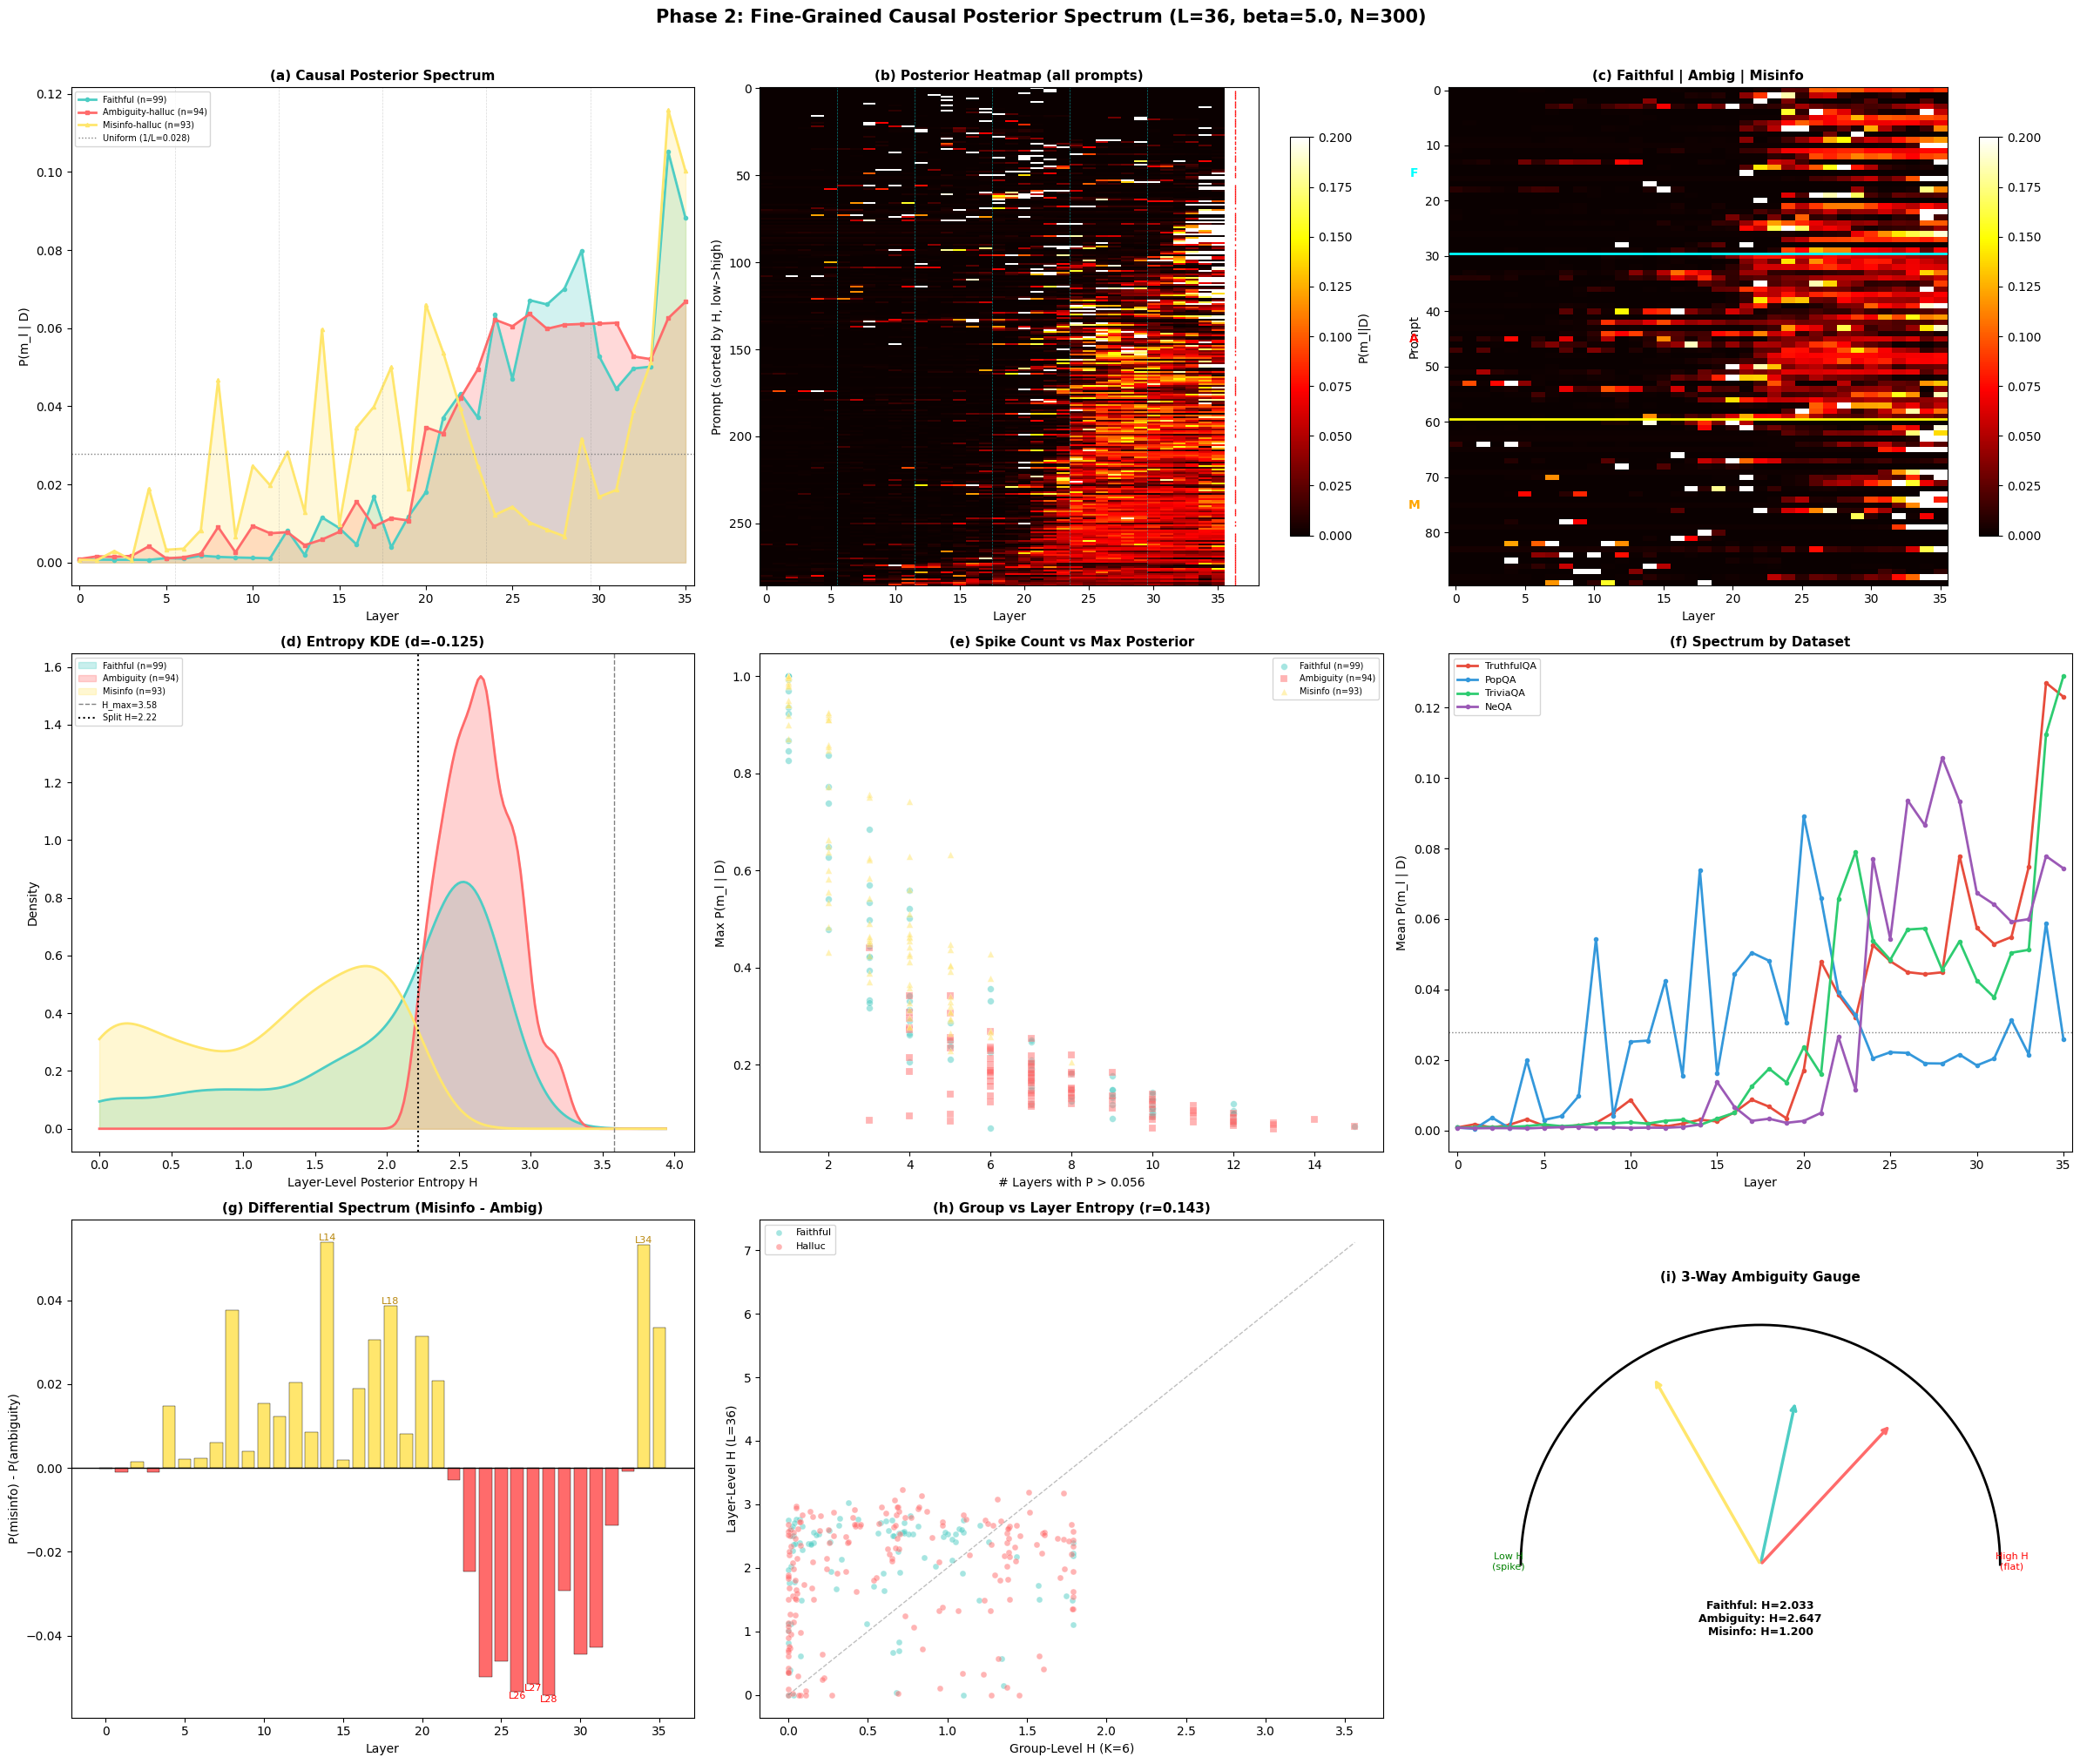

Saved causal_spectrum.png


In [3]:
# ── Classify hallucinations into subtypes ──
# Use median entropy of hallucinated prompts as threshold
H_halluc_all = layer_ent[mask_h]
H_median = np.median(H_halluc_all)
ambiguity_mask = mask_h & (layer_ent >= H_median)  # high H = ambiguity-driven
misinfo_mask = mask_h & (layer_ent < H_median)      # low H = misinformation-driven

print(f"Hallucination subtypes (threshold H_median = {H_median:.4f}):")
print(f"  Ambiguity-driven:    {ambiguity_mask.sum()}")
print(f"  Misinformation-driven: {misinfo_mask.sum()}")

# ── Compute average spectra per group ──
spectrum_faithful = layer_post[mask_f].mean(axis=0)  # (36,)
spectrum_ambig = layer_post[ambiguity_mask].mean(axis=0)
spectrum_misinfo = layer_post[misinfo_mask].mean(axis=0)
uniform = np.ones(L) / L

# ── Peak analysis ──
def analyze_spectrum(spectrum, label):
    peaks, props = find_peaks(spectrum, height=2.0/L, prominence=0.5/L)
    max_layer = np.argmax(spectrum)
    max_val = spectrum[max_layer]
    gini = 1 - np.sum(spectrum**2) / (np.sum(spectrum))**2 * L  # normalized
    concentration = np.sum(np.sort(spectrum)[-3:])  # top-3 concentration
    print(f"  {label:>20s}: peak L{max_layer} ({max_val:.3f}), top3={concentration:.3f}, n_peaks={len(peaks)}")
    return peaks, max_layer

print(f"\nSpectral analysis:")
peaks_f, _ = analyze_spectrum(spectrum_faithful, 'Faithful')
peaks_a, _ = analyze_spectrum(spectrum_ambig, 'Ambiguity-type')
peaks_m, _ = analyze_spectrum(spectrum_misinfo, 'Misinfo-type')

# ══════════════════════════════════════════════════════════════
# MEGA FIGURE: 8-panel Causal Posterior Spectrum
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(24, 20))
colors = {'faithful': '#4ECDC4', 'ambiguity': '#FF6B6B', 'misinfo': '#FFE66D'}
ds_colors = {'TruthfulQA': '#E74C3C', 'PopQA': '#3498DB', 'TriviaQA': '#2ECC71', 'NeQA': '#9B59B6'}

# ── (a) THE Causal Posterior Spectrum: 3-line overlay ──
ax1 = fig.add_subplot(3, 3, 1)
layers = np.arange(L)
ax1.fill_between(layers, spectrum_faithful, alpha=0.25, color=colors['faithful'])
ax1.plot(layers, spectrum_faithful, '-o', color=colors['faithful'], lw=2, ms=3, label=f'Faithful (n={mask_f.sum()})')
ax1.fill_between(layers, spectrum_ambig, alpha=0.25, color=colors['ambiguity'])
ax1.plot(layers, spectrum_ambig, '-s', color=colors['ambiguity'], lw=2, ms=3, label=f'Ambiguity-halluc (n={ambiguity_mask.sum()})')
ax1.fill_between(layers, spectrum_misinfo, alpha=0.25, color=colors['misinfo'])
ax1.plot(layers, spectrum_misinfo, '-^', color=colors['misinfo'], lw=2, ms=3, label=f'Misinfo-halluc (n={misinfo_mask.sum()})')
ax1.axhline(1/L, color='grey', ls=':', lw=1, label=f'Uniform (1/L={1/L:.3f})')
ax1.set_xlabel('Layer')
ax1.set_ylabel('P(m_l | D)')
ax1.set_title('(a) Causal Posterior Spectrum', fontweight='bold', fontsize=11)
ax1.legend(fontsize=7, loc='upper left')
ax1.set_xlim(-0.5, L-0.5)
for b in [6, 12, 18, 24, 30]:
    ax1.axvline(b-0.5, color='grey', ls='--', lw=0.5, alpha=0.3)

# ── (b) Heatmap: ALL prompts sorted by entropy ──
ax2 = fig.add_subplot(3, 3, 2)
sig_idx = np.where(significant)[0]
order = sig_idx[np.argsort(layer_ent[sig_idx])]
im = ax2.imshow(layer_post[order], aspect='auto', cmap='hot', vmin=0, vmax=0.2,
                interpolation='nearest')
ax2.set_xlabel('Layer')
ax2.set_ylabel('Prompt (sorted by H, low->high)')
ax2.set_title('(b) Posterior Heatmap (all prompts)', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax2, shrink=0.8, label='P(m_l|D)')
for b in [6, 12, 18, 24, 30]:
    ax2.axvline(b-0.5, color='cyan', lw=0.5, ls='--', alpha=0.5)
# Mark hallucinated prompts
halluc_positions = [np.where(order == idx)[0][0] for idx in np.where(mask_h)[0] if idx in order]
for hp in halluc_positions:
    ax2.plot(L + 0.3, hp, 'r|', ms=2)

# ── (c) Heatmap: Faithful vs Ambiguity vs Misinfo side by side ──
ax3 = fig.add_subplot(3, 3, 3)
n_show = 30
# Stack: faithful top, ambiguity middle, misinfo bottom
f_idx = np.where(mask_f)[0]
a_idx = np.where(ambiguity_mask)[0]
m_idx = np.where(misinfo_mask)[0]
rng = np.random.RandomState(42)
f_sample = f_idx[rng.choice(len(f_idx), min(n_show, len(f_idx)), replace=False)]
a_sample = a_idx[rng.choice(len(a_idx), min(n_show, len(a_idx)), replace=False)]
m_sample = m_idx[rng.choice(len(m_idx), min(n_show, len(m_idx)), replace=False)]
combined = np.concatenate([f_sample, a_sample, m_sample])
combined_post = layer_post[combined]
im3 = ax3.imshow(combined_post, aspect='auto', cmap='hot', vmin=0, vmax=0.2, interpolation='nearest')
ax3.axhline(len(f_sample)-0.5, color='cyan', lw=2)
ax3.axhline(len(f_sample)+len(a_sample)-0.5, color='yellow', lw=2)
ax3.set_xlabel('Layer')
ax3.set_ylabel('Prompt')
ax3.set_title('(c) Faithful | Ambig | Misinfo', fontweight='bold', fontsize=11)
plt.colorbar(im3, ax=ax3, shrink=0.8)
ax3.text(-3, len(f_sample)//2, 'F', fontweight='bold', color='cyan', ha='center', va='center', fontsize=10)
ax3.text(-3, len(f_sample)+len(a_sample)//2, 'A', fontweight='bold', color='red', ha='center', va='center', fontsize=10)
ax3.text(-3, len(f_sample)+len(a_sample)+len(m_sample)//2, 'M', fontweight='bold', color='orange', ha='center', va='center', fontsize=10)

# ── (d) Layer entropy distribution ──
ax4 = fig.add_subplot(3, 3, 4)
x_range = np.linspace(0, H_max_layer * 1.1, 200)
for label, arr, color in [('Faithful', H_f_layer, colors['faithful']),
                           ('Ambiguity', layer_ent[ambiguity_mask], colors['ambiguity']),
                           ('Misinfo', layer_ent[misinfo_mask], colors['misinfo'])]:
    if len(arr) > 2:
        kde = stats.gaussian_kde(arr, bw_method=0.3)
        ax4.fill_between(x_range, kde(x_range), alpha=0.3, color=color, label=f'{label} (n={len(arr)})')
        ax4.plot(x_range, kde(x_range), color=color, lw=2)
ax4.axvline(H_max_layer, color='grey', ls='--', lw=1, label=f'H_max={H_max_layer:.2f}')
ax4.axvline(H_median, color='black', ls=':', lw=1.5, label=f'Split H={H_median:.2f}')
ax4.set_xlabel('Layer-Level Posterior Entropy H')
ax4.set_ylabel('Density')
ax4.set_title(f'(d) Entropy KDE (d={cohen_d_layer:.3f})', fontweight='bold', fontsize=11)
ax4.legend(fontsize=7)

# ── (e) Spike count analysis ──
ax5 = fig.add_subplot(3, 3, 5)
# For each prompt, count layers with P > threshold
threshold = 2.0 / L  # 2x uniform
spike_counts = (layer_post > threshold).sum(axis=1)
# Dominant layer concentration: max P value
max_P = layer_post.max(axis=1)

for label, mask, color, marker in [('Faithful', mask_f, colors['faithful'], 'o'),
                                    ('Ambiguity', ambiguity_mask, colors['ambiguity'], 's'),
                                    ('Misinfo', misinfo_mask, colors['misinfo'], '^')]:
    ax5.scatter(spike_counts[mask], max_P[mask], c=color, alpha=0.5, s=30, marker=marker, 
                edgecolors='white', lw=0.3, label=f'{label} (n={mask.sum()})')
ax5.set_xlabel(f'# Layers with P > {threshold:.3f}')
ax5.set_ylabel('Max P(m_l | D)')
ax5.set_title('(e) Spike Count vs Max Posterior', fontweight='bold', fontsize=11)
ax5.legend(fontsize=7)

# ── (f) Per-dataset spectrum overlay ──
ax6 = fig.add_subplot(3, 3, 6)
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    dm = (ds_labels == ds_name) & significant
    if dm.sum() > 0:
        spec = layer_post[dm].mean(axis=0)
        ax6.plot(layers, spec, '-o', ms=3, lw=2, color=ds_colors[ds_name], label=ds_name)
ax6.axhline(1/L, color='grey', ls=':', lw=1)
ax6.set_xlabel('Layer')
ax6.set_ylabel('Mean P(m_l | D)')
ax6.set_title('(f) Spectrum by Dataset', fontweight='bold', fontsize=11)
ax6.legend(fontsize=8)
ax6.set_xlim(-0.5, L-0.5)

# ── (g) Critical layer identification ──
ax7 = fig.add_subplot(3, 3, 7)
# Compute difference: misinfo - ambiguity spectrum
diff_spectrum = spectrum_misinfo - spectrum_ambig
ax7.bar(layers, diff_spectrum, color=np.where(diff_spectrum > 0, '#FFE66D', '#FF6B6B'),
        edgecolor='black', lw=0.3)
ax7.axhline(0, color='black', lw=1)
ax7.set_xlabel('Layer')
ax7.set_ylabel('P(misinfo) - P(ambiguity)')
ax7.set_title('(g) Differential Spectrum (Misinfo - Ambig)', fontweight='bold', fontsize=11)
# Annotate top 3 positive and negative
top_pos = np.argsort(diff_spectrum)[-3:][::-1]
top_neg = np.argsort(diff_spectrum)[:3]
for l in top_pos:
    if diff_spectrum[l] > 0.005:
        ax7.annotate(f'L{l}', xy=(l, diff_spectrum[l]), fontsize=8, ha='center', va='bottom', color='darkgoldenrod')
for l in top_neg:
    if diff_spectrum[l] < -0.005:
        ax7.annotate(f'L{l}', xy=(l, diff_spectrum[l]), fontsize=8, ha='center', va='top', color='red')

# ── (h) Layer-level vs Group-level entropy scatter ──
ax8 = fig.add_subplot(3, 3, 8)
for label, mask, color in [('Faithful', mask_f, colors['faithful']),
                            ('Halluc', mask_h, '#FF6B6B')]:
    ax8.scatter(entropies_grp[mask], layer_ent[mask], c=color, alpha=0.5, s=25, 
                edgecolors='white', lw=0.3, label=label)
# Correlation
r, p_corr = stats.pearsonr(entropies_grp[significant], layer_ent[significant])
ax8.set_xlabel('Group-Level H (K=6)')
ax8.set_ylabel('Layer-Level H (L=36)')
ax8.set_title(f'(h) Group vs Layer Entropy (r={r:.3f})', fontweight='bold', fontsize=11)
ax8.legend(fontsize=8)
# Diagonal reference
lims = [0, max(entropies_grp[significant].max(), layer_ent[significant].max()) * 1.1]
ax8.plot([0, lims[1]], [0, lims[1] * H_max_layer / np.log(6)], 'grey', ls='--', lw=1, alpha=0.5)

# ── (i) Summary gauge: 3-needle ──
ax9 = fig.add_subplot(3, 3, 9)
theta = np.linspace(np.pi, 0, 200)
ax9.plot(np.cos(theta), np.sin(theta), 'k-', lw=2)
for label, H_mean, color, radius in [('Faithful', H_f_layer.mean(), colors['faithful'], 0.7),
                                       ('Ambiguity', layer_ent[ambiguity_mask].mean(), colors['ambiguity'], 0.8),
                                       ('Misinfo', layer_ent[misinfo_mask].mean(), colors['misinfo'], 0.9)]:
    frac = H_mean / H_max_layer if H_max_layer > 0 else 0
    angle = np.pi * (1 - frac)
    ax9.annotate('', xy=(radius*np.cos(angle), radius*np.sin(angle)), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
ax9.text(0, -0.15, f'Faithful: H={H_f_layer.mean():.3f}\n'
         f'Ambiguity: H={layer_ent[ambiguity_mask].mean():.3f}\n'
         f'Misinfo: H={layer_ent[misinfo_mask].mean():.3f}',
         ha='center', va='top', fontsize=9, fontweight='bold')
ax9.text(-1.05, -0.02, 'Low H\n(spike)', ha='center', fontsize=8, color='green')
ax9.text(1.05, -0.02, 'High H\n(flat)', ha='center', fontsize=8, color='red')
ax9.set_xlim(-1.3, 1.3); ax9.set_ylim(-0.35, 1.15)
ax9.set_aspect('equal'); ax9.axis('off')
ax9.set_title('(i) 3-Way Ambiguity Gauge', fontweight='bold', fontsize=11)

fig.suptitle(f'Phase 2: Fine-Grained Causal Posterior Spectrum (L={L}, beta={beta}, N={N})',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/workspace/Data/bayesian_phase2/causal_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved causal_spectrum.png")

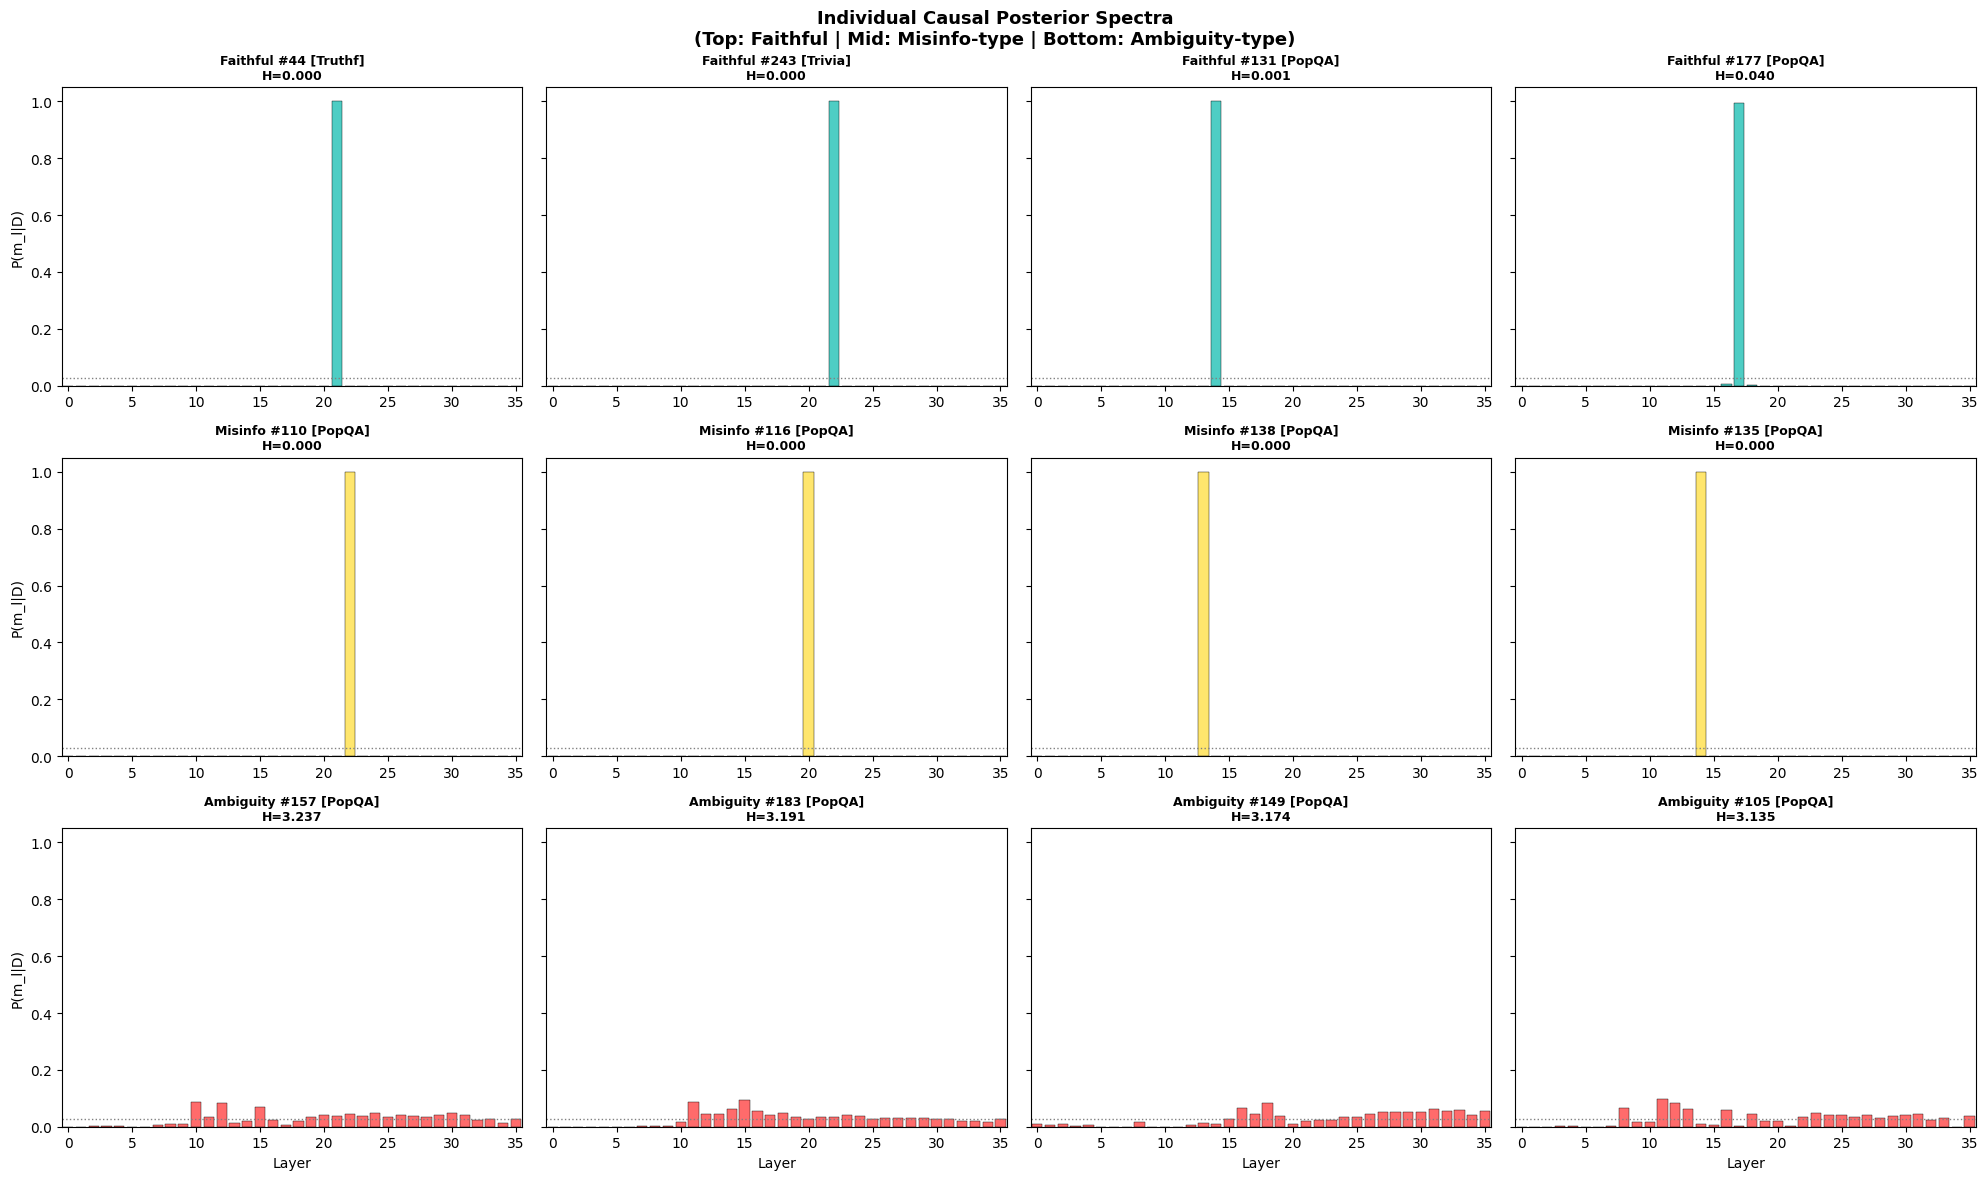

Saved individual_spectra.png


In [4]:
# Show individual spectra for the most extreme examples
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)

# Row 0: Faithful examples (lowest entropy)
f_by_ent = np.argsort(layer_ent[mask_f])
f_indices = np.where(mask_f)[0]
for col in range(4):
    ax = axes[0, col]
    if col < len(f_by_ent):
        idx = f_indices[f_by_ent[col]]  # lowest entropy faithful
        ax.bar(range(L), layer_post[idx], color=colors['faithful'], edgecolor='black', lw=0.3)
        ax.axhline(1/L, color='grey', ls=':', lw=1)
        ds = ds_labels[idx]
        ax.set_title(f'Faithful #{idx} [{ds[:6]}]\nH={layer_ent[idx]:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlim(-0.5, L-0.5)
    if col == 0: ax.set_ylabel('P(m_l|D)')

# Row 1: Misinfo hallucinations (lowest entropy halluc)
h_by_ent = np.argsort(layer_ent[mask_h])
h_indices = np.where(mask_h)[0]
for col in range(4):
    ax = axes[1, col]
    if col < len(h_by_ent):
        idx = h_indices[h_by_ent[col]]  # lowest entropy halluc = misinfo
        ax.bar(range(L), layer_post[idx], color=colors['misinfo'], edgecolor='black', lw=0.3)
        ax.axhline(1/L, color='grey', ls=':', lw=1)
        ds = ds_labels[idx]
        ax.set_title(f'Misinfo #{idx} [{ds[:6]}]\nH={layer_ent[idx]:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlim(-0.5, L-0.5)
    if col == 0: ax.set_ylabel('P(m_l|D)')

# Row 2: Ambiguity hallucinations (highest entropy halluc)
for col in range(4):
    ax = axes[2, col]
    rev_idx = len(h_by_ent) - 1 - col
    if rev_idx >= 0:
        idx = h_indices[h_by_ent[rev_idx]]  # highest entropy halluc = ambiguity
        ax.bar(range(L), layer_post[idx], color=colors['ambiguity'], edgecolor='black', lw=0.3)
        ax.axhline(1/L, color='grey', ls=':', lw=1)
        ds = ds_labels[idx]
        ax.set_title(f'Ambiguity #{idx} [{ds[:6]}]\nH={layer_ent[idx]:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlim(-0.5, L-0.5)
    if col == 0: ax.set_ylabel('P(m_l|D)')
    ax.set_xlabel('Layer')

fig.suptitle('Individual Causal Posterior Spectra\n(Top: Faithful | Mid: Misinfo-type | Bottom: Ambiguity-type)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/Data/bayesian_phase2/individual_spectra.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved individual_spectra.png")

In [5]:
print("=" * 60)
print("CRITICAL LAYER ANALYSIS")
print("=" * 60)

# For each group, find the dominant layer (argmax of mean posterior)
for label, mask, color in [('Faithful', mask_f, 'cyan'),
                            ('Ambiguity', ambiguity_mask, 'red'),
                            ('Misinfo', misinfo_mask, 'orange')]:
    spec = layer_post[mask].mean(axis=0)
    top5 = np.argsort(spec)[-5:][::-1]
    print(f"\n{label} (n={mask.sum()}):")
    print(f"  Top-5 layers: {', '.join(f'L{l} ({spec[l]:.4f})' for l in top5)}")
    print(f"  Top-5 concentration: {spec[top5].sum():.3f}")
    
    # Per-layer posterior variance (which layers are most variable?)
    var_per_layer = layer_post[mask].var(axis=0)
    top_var = np.argsort(var_per_layer)[-3:][::-1]
    print(f"  Most variable layers: {', '.join(f'L{l} (var={var_per_layer[l]:.5f})' for l in top_var)}")

# Spectral features for classification
print(f"\n{'='*60}")
print("SPECTRAL FEATURES FOR HALLUCINATION SUBTYPING")
print(f"{'='*60}")

# Compute features for each prompt
features = {}
features['max_P'] = layer_post.max(axis=1)
features['argmax_P'] = layer_post.argmax(axis=1)
features['n_active'] = (layer_post > 2/L).sum(axis=1)  # layers above 2x uniform
features['top3_conc'] = np.sort(layer_post, axis=1)[:, -3:].sum(axis=1)
features['gini'] = 1 - np.sum(layer_post**2, axis=1)  # 1 - Herfindahl index
features['early_mass'] = layer_post[:, :12].sum(axis=1)  # L0-11
features['mid_mass'] = layer_post[:, 12:24].sum(axis=1)   # L12-23
features['late_mass'] = layer_post[:, 24:].sum(axis=1)    # L24-35

print(f"\n{'Feature':>15s}  {'Faithful':>10s}  {'Ambiguity':>10s}  {'Misinfo':>10s}")
print("-" * 52)
for fname, fval in features.items():
    f_mean = fval[mask_f].mean()
    a_mean = fval[ambiguity_mask].mean()
    m_mean = fval[misinfo_mask].mean()
    print(f"{fname:>15s}  {f_mean:10.4f}  {a_mean:10.4f}  {m_mean:10.4f}")

# Where do misinfo spikes concentrate?
print(f"\nMisinfo spike locations (argmax histogram):")
misinfo_peaks = features['argmax_P'][misinfo_mask]
peak_hist = np.bincount(misinfo_peaks, minlength=L)
top_peak_layers = np.argsort(peak_hist)[-5:][::-1]
for l in top_peak_layers:
    print(f"  L{l}: {peak_hist[l]} prompts ({peak_hist[l]/misinfo_mask.sum()*100:.0f}%)")

CRITICAL LAYER ANALYSIS

Faithful (n=99):
  Top-5 layers: L34 (0.1052), L35 (0.0882), L29 (0.0799), L28 (0.0701), L26 (0.0672)
  Top-5 concentration: 0.410
  Most variable layers: L34 (var=0.02770), L22 (var=0.02133), L21 (var=0.01914)

Ambiguity (n=94):
  Top-5 layers: L35 (0.0668), L26 (0.0636), L34 (0.0625), L24 (0.0622), L31 (0.0614)
  Top-5 concentration: 0.316
  Most variable layers: L20 (var=0.00524), L34 (var=0.00331), L24 (var=0.00244)

Misinfo (n=93):
  Top-5 layers: L34 (0.1158), L35 (0.1002), L20 (0.0660), L14 (0.0597), L21 (0.0538)
  Top-5 concentration: 0.396
  Most variable layers: L14 (var=0.04641), L34 (var=0.03723), L8 (var=0.03349)

SPECTRAL FEATURES FOR HALLUCINATION SUBTYPING

        Feature    Faithful   Ambiguity     Misinfo
----------------------------------------------------
          max_P      0.3215      0.1634      0.5947
       argmax_P     27.5960     25.1596     22.8495
       n_active      6.3737      7.7234      3.1505
      top3_conc      0.5640     

## Attention vs MLP Proxy Analysis

NeuroScope's `apply_steering` operates on the full residual stream, so we cannot directly patch Attention vs MLP separately. However, we CAN compute the **residual stream contribution** of each layer:

    layer_contrib[l] = acts[l] - acts[l-1]

This tells us HOW MUCH each layer changes the representation. By comparing clean vs corrupt contributions, we can identify which layers are doing the heaviest computation differently — a proxy for where attn/mlp diverge.

In [6]:
# ── Attn/MLP proxy: Residual Contribution Analysis ──
# Re-run clean/corrupt forward passes for a subset to capture full activation trajectories

from datasets import load_dataset
rng_sub = np.random.RandomState(123)

# Load prompts from Phase 1b
with open('/workspace/Data/bayesian_phase1b/summary.json') as f:
    summary_1b = json.load(f)

# We need the original prompts — reload from Phase 1b kernel if alive, else reconstruct
# Select 50 representative prompts: 25 faithful, 25 hallucinated (balanced)
f_indices_all = np.where(mask_f)[0]
h_indices_all = np.where(mask_h)[0]

# Stratify: pick from each entropy quartile
def stratified_sample(indices, ents, n=25):
    quartiles = np.percentile(ents[indices], [25, 50, 75])
    q_masks = [
        ents[indices] <= quartiles[0],
        (ents[indices] > quartiles[0]) & (ents[indices] <= quartiles[1]),
        (ents[indices] > quartiles[1]) & (ents[indices] <= quartiles[2]),
        ents[indices] > quartiles[2]
    ]
    selected = []
    per_q = n // 4
    for qm in q_masks:
        q_idx = indices[qm]
        rng_sub.shuffle(q_idx)
        selected.extend(q_idx[:per_q].tolist())
    # Fill remainder
    remaining = [i for i in indices if i not in selected]
    rng_sub.shuffle(remaining)
    selected.extend(remaining[:n - len(selected)])
    return selected[:n]

sample_f = stratified_sample(f_indices_all, layer_ent, 25)
sample_h = stratified_sample(h_indices_all, layer_ent, 25)
sample_indices = sorted(sample_f + sample_h)

print(f"Residual contribution analysis: {len(sample_indices)} prompts")
print(f"  Faithful: {len(sample_f)}, Hallucinated: {len(sample_h)}")

# We need the original prompts. Reconstruct from Phase 1b data.
# The prompts were stored in gen_results in Phase 1b kernel. Let's reload datasets.
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
CORRUPT_ENTITY = "Zyxwv"

# Reload all prompts (same as Phase 1b Cell 3)
tqa = load_dataset('truthful_qa', 'generation', split='validation')
pqa = load_dataset('akariasai/PopQA', split='test')
trivia = load_dataset('trivia_qa', 'rc.nocontext', split='validation')
neqa = load_dataset('inverse-scaling/NeQA', split='train')
print("Datasets reloaded for prompt reconstruction")

Residual contribution analysis: 50 prompts
  Faithful: 25, Hallucinated: 25


Repo card metadata block was not found. Setting CardData to empty.


Datasets reloaded for prompt reconstruction


In [7]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def strip_think(text):
    return re.sub(r"<think>.*?</think>\s*", "", text, flags=re.DOTALL)

# Reconstruct prompt list (same logic as Phase 1b)
import json as json_mod
rng_r = np.random.RandomState(42)  # SAME seed as Phase 1b

prop_templates = {
    'occupation': "The occupation of {} is",
    'genre': "The genre of {} is",
    'country': "The country of {} is",
    'capital': "The capital of {} is",
    'place of birth': "The birthplace of {} is",
    'author': "The author of {} is",
    'director': "The director of {} is",
    'producer': "The producer of {} is",
    'screenwriter': "The screenwriter of {} is",
    'composer': "The composer of {} is",
    'color': "The color of {} is",
    'religion': "The religion of {} is",
    'sport': "The sport of {} is",
    'continent': "The continent of {} is",
    'has_part': "{} contains",
    'mother': "The mother of {} is",
    'father': "The father of {} is",
    'child': "A child of {} is",
}

all_prompts = []

# TruthfulQA
tqa_prompts = []
for row in tqa:
    q = row['question']; correct = row['correct_answers']; best = row['best_answer']
    m = re.search(r'(?:What|Where|When|Who|How)\s+(?:is|are|was|were|did)\s+(?:the\s+)?(.+?)(?:\?|$)', q, re.I)
    if not m: continue
    subject = m.group(1).strip().rstrip('?').strip()
    if not subject or len(subject)<3 or len(subject)>60: continue
    expected = correct if correct else [best]
    tqa_prompts.append((f"Q: {q}\nA:", subject, expected, 'TruthfulQA'))
rng_r.shuffle(tqa_prompts)
all_prompts.extend(tqa_prompts[:100])

# PopQA
pqa_prompts = []
for row in pqa:
    prop = row['prop']; subj = row['subj']; obj = row['obj']
    template = prop_templates.get(prop, f"The {prop} of " + "{}" + " is")
    prompt = template.format(subj)
    try: answers = json_mod.loads(row['possible_answers'])
    except: answers = [obj]
    if obj not in answers: answers.insert(0, obj)
    pqa_prompts.append((prompt, subj, answers, 'PopQA', row['s_pop']))
pqa_prompts.sort(key=lambda x: x[4])
pqa_low = pqa_prompts[:2000]
rng_r.shuffle(pqa_low)
all_prompts.extend([(p,s,a,d) for p,s,a,d,_ in pqa_low[:100]])

# TriviaQA
trivia_prompts = []
for row in trivia:
    q = row['question']; answer = row['answer']
    aliases = answer.get('aliases',[]); value = answer.get('value','')
    m = re.search(r"(?:What|Where|When|Who|Which|How)\s+(?:is|are|was|were|did)\s+(?:the\s+)?(.+?)(?:\?|$)", q, re.I)
    if not m: continue
    subject = m.group(1).strip().rstrip('?').strip()
    if not subject or len(subject)<3 or len(subject)>60: continue
    expected = aliases if aliases else [value]
    if value and value not in expected: expected.insert(0, value)
    trivia_prompts.append((f"Q: {q}\nA:", subject, expected, 'TriviaQA'))
rng_r.shuffle(trivia_prompts)
all_prompts.extend(trivia_prompts[:50])

# NeQA
neqa_prompts = []
for row in neqa:
    prompt_text = row['prompt']; classes = row['classes']; answer_idx = row['answer_index']
    m = re.search(r'Question:\s*(.+?)(?:\nA\.)', prompt_text, re.DOTALL)
    if not m: continue
    question = m.group(1).strip()
    m2 = re.search(r'(?:a |an |the )?(\w[\w\s]{2,30}?)(?:\s+(?:has|is|are|was|were|does|do|did|can|will|isn|aren|doesn|don|wasn|weren|cannot|won))', question, re.I)
    subject = m2.group(1).strip() if m2 else question[:30]
    if not subject or len(subject)<2: subject = question[:30]
    neqa_prompts.append((prompt_text, subject, [classes[answer_idx].strip()], 'NeQA'))
rng_r.shuffle(neqa_prompts)
all_prompts.extend(neqa_prompts[:50])

print(f"Reconstructed {len(all_prompts)} prompts")

# ── Run residual contribution analysis on subset ──
print(f"\nRunning residual contribution analysis on {len(sample_indices)} prompts...")

# For each prompt: get clean_acts and corrupt_acts, compute per-layer contribution
layer_contrib_clean = np.zeros((len(sample_indices), L, n_embd), dtype=np.float32)
layer_contrib_corrupt = np.zeros((len(sample_indices), L, n_embd), dtype=np.float32)
contrib_diff_norm = np.zeros((len(sample_indices), L))  # ||clean_contrib - corrupt_contrib||
contrib_cosine = np.zeros((len(sample_indices), L))     # cosine similarity

t0 = time.time()
for si, idx in enumerate(sample_indices):
    prompt, subject, answers, ds_name = all_prompts[idx]
    corrupt_prompt = prompt.replace(subject, CORRUPT_ENTITY, 1)
    if corrupt_prompt == prompt:
        corrupt_prompt = CORRUPT_ENTITY + " " + prompt
    
    # Clean pass
    engine.reset()
    engine.forward(prompt)
    clean_acts = [a.copy() for a in engine.get_all_activations()]
    
    # Corrupt pass
    engine.reset()
    engine.forward(corrupt_prompt)
    corrupt_acts = [a.copy() for a in engine.get_all_activations()]
    
    # Per-layer residual contribution
    for l in range(L):
        if l == 0:
            c_contrib = clean_acts[l]
            x_contrib = corrupt_acts[l]
        else:
            c_contrib = clean_acts[l] - clean_acts[l-1]
            x_contrib = corrupt_acts[l] - corrupt_acts[l-1]
        
        layer_contrib_clean[si, l] = c_contrib
        layer_contrib_corrupt[si, l] = x_contrib
        
        diff = c_contrib - x_contrib
        contrib_diff_norm[si, l] = np.linalg.norm(diff)
        
        # Cosine similarity
        norm_c = np.linalg.norm(c_contrib)
        norm_x = np.linalg.norm(x_contrib)
        if norm_c > 1e-10 and norm_x > 1e-10:
            contrib_cosine[si, l] = np.dot(c_contrib, x_contrib) / (norm_c * norm_x)
        else:
            contrib_cosine[si, l] = 1.0
    
    if (si+1) % 10 == 0:
        print(f"  [{si+1}/{len(sample_indices)}] {time.time()-t0:.1f}s")

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s ({len(sample_indices)*2} forward passes)")

# Map sample indices to faithful/halluc
sample_is_f = is_faithful[sample_indices]
sample_ent = layer_ent[sample_indices]
sample_ds = ds_labels[sample_indices]

Reconstructed 300 prompts

Running residual contribution analysis on 50 prompts...
  [10/50] 1.3s
  [20/50] 2.6s
  [30/50] 3.8s
  [40/50] 5.0s
  [50/50] 6.4s

Done in 6.4s (100 forward passes)


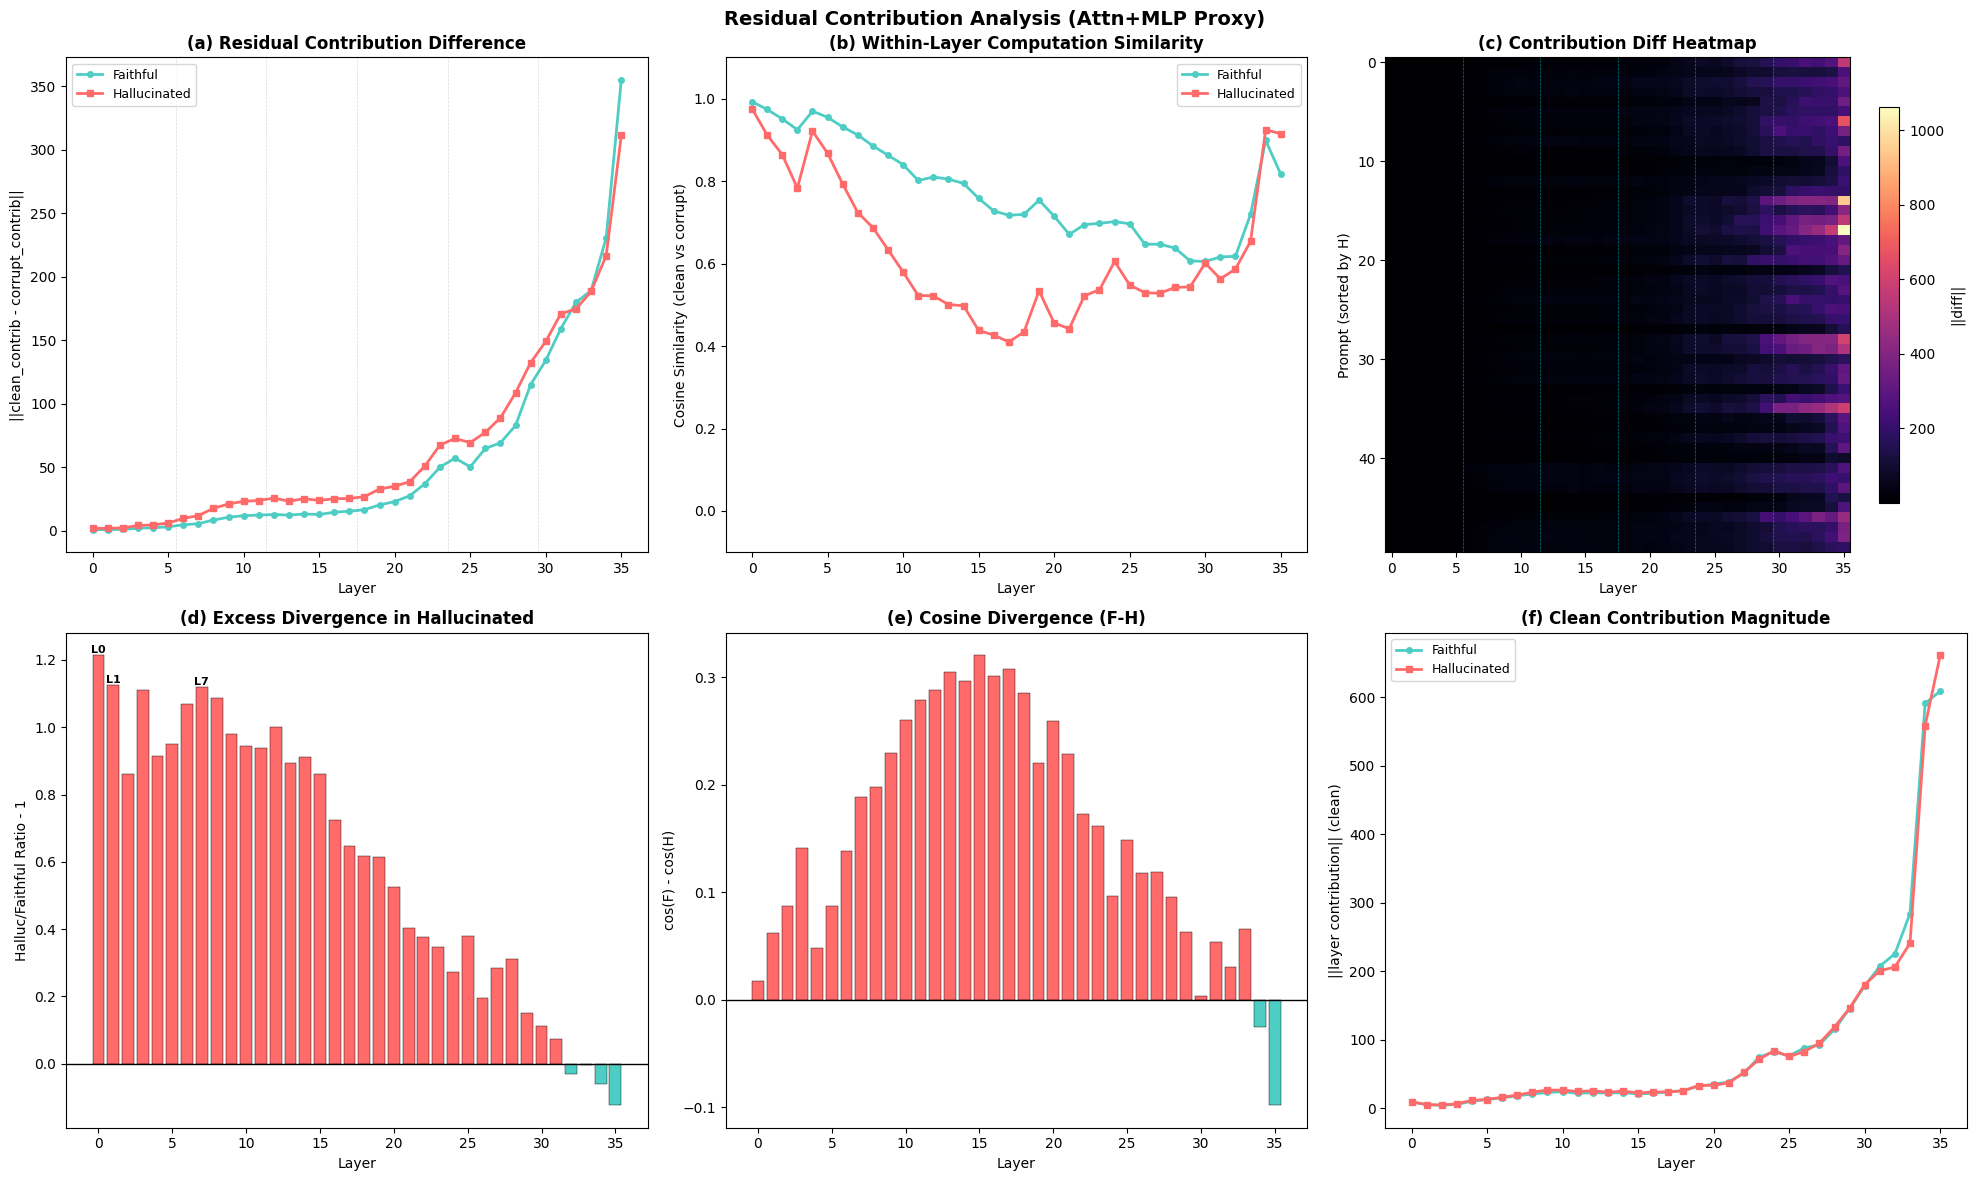

Saved residual_contribution.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ── (a) Mean ||delta_contrib|| per layer ──
ax = axes[0, 0]
f_mask_s = sample_is_f
h_mask_s = ~sample_is_f
mean_diff_f = contrib_diff_norm[f_mask_s].mean(axis=0)
mean_diff_h = contrib_diff_norm[h_mask_s].mean(axis=0)
ax.plot(range(L), mean_diff_f, '-o', ms=4, color=colors['faithful'], lw=2, label='Faithful')
ax.plot(range(L), mean_diff_h, '-s', ms=4, color='#FF6B6B', lw=2, label='Hallucinated')
ax.set_xlabel('Layer')
ax.set_ylabel('||clean_contrib - corrupt_contrib||')
ax.set_title('(a) Residual Contribution Difference', fontweight='bold')
ax.legend(fontsize=9)
for b in [6, 12, 18, 24, 30]:
    ax.axvline(b-0.5, color='grey', ls='--', lw=0.5, alpha=0.3)

# ── (b) Cosine similarity per layer ──
ax = axes[0, 1]
mean_cos_f = contrib_cosine[f_mask_s].mean(axis=0)
mean_cos_h = contrib_cosine[h_mask_s].mean(axis=0)
ax.plot(range(L), mean_cos_f, '-o', ms=4, color=colors['faithful'], lw=2, label='Faithful')
ax.plot(range(L), mean_cos_h, '-s', ms=4, color='#FF6B6B', lw=2, label='Hallucinated')
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine Similarity (clean vs corrupt)')
ax.set_title('(b) Within-Layer Computation Similarity', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-0.1, 1.1)

# ── (c) Heatmap of contribution diff norms ──
ax = axes[0, 2]
order_s = np.argsort(sample_ent)
im = ax.imshow(contrib_diff_norm[order_s], aspect='auto', cmap='magma', interpolation='nearest')
ax.set_xlabel('Layer')
ax.set_ylabel('Prompt (sorted by H)')
ax.set_title('(c) Contribution Diff Heatmap', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='||diff||')
for b in [6, 12, 18, 24, 30]:
    ax.axvline(b-0.5, color='cyan', lw=0.5, ls='--', alpha=0.5)

# ── (d) Diff norm ratio: which layers diverge more for halluc? ──
ax = axes[1, 0]
ratio = mean_diff_h / (mean_diff_f + 1e-10)
ax.bar(range(L), ratio - 1, color=np.where(ratio > 1, '#FF6B6B', '#4ECDC4'),
       edgecolor='black', lw=0.3)
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Layer')
ax.set_ylabel('Halluc/Faithful Ratio - 1')
ax.set_title('(d) Excess Divergence in Hallucinated', fontweight='bold')
# Annotate high-divergence layers
top_div = np.argsort(ratio)[-3:][::-1]
for l in top_div:
    ax.annotate(f'L{l}', xy=(l, ratio[l]-1), fontsize=8, ha='center', va='bottom', fontweight='bold')

# ── (e) Cosine diff: where does computation change most? ──
ax = axes[1, 1]
cos_diff = mean_cos_f - mean_cos_h  # positive = halluc less similar
ax.bar(range(L), cos_diff, color=np.where(cos_diff > 0, '#FF6B6B', '#4ECDC4'),
       edgecolor='black', lw=0.3)
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Layer')
ax.set_ylabel('cos(F) - cos(H)')
ax.set_title('(e) Cosine Divergence (F-H)', fontweight='bold')

# ── (f) Contribution magnitude per layer (clean) ──
ax = axes[1, 2]
clean_norm_f = np.linalg.norm(layer_contrib_clean[f_mask_s], axis=2).mean(axis=0)
clean_norm_h = np.linalg.norm(layer_contrib_clean[h_mask_s], axis=2).mean(axis=0)
ax.plot(range(L), clean_norm_f, '-o', ms=4, color=colors['faithful'], lw=2, label='Faithful')
ax.plot(range(L), clean_norm_h, '-s', ms=4, color='#FF6B6B', lw=2, label='Hallucinated')
ax.set_xlabel('Layer')
ax.set_ylabel('||layer contribution|| (clean)')
ax.set_title('(f) Clean Contribution Magnitude', fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle('Residual Contribution Analysis (Attn+MLP Proxy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/Data/bayesian_phase2/residual_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved residual_contribution.png")

In [9]:
# Save all results
np.savez('/workspace/Data/bayesian_phase2/phase2_results.npz',
    layer_posteriors=layer_post,       # (300, 36)
    layer_entropies=layer_ent,         # (300,)
    IE_per_layer=IE_per_layer,         # (300, 36)
    is_faithful=is_faithful,
    significant=significant,
    ds_labels=ds_labels,
    ambiguity_mask=ambiguity_mask,
    misinfo_mask=misinfo_mask,
    mask_f=mask_f, mask_h=mask_h,
    spectrum_faithful=spectrum_faithful,
    spectrum_ambig=spectrum_ambig,
    spectrum_misinfo=spectrum_misinfo,
    contrib_diff_norm=contrib_diff_norm,  # (50, 36)
    contrib_cosine=contrib_cosine,        # (50, 36)
    sample_indices=np.array(sample_indices),
    beta=beta,
    cohen_d_layer=cohen_d_layer,
)

# Summary JSON
summary = {
    'phase': '2',
    'description': 'Fine-grained layer-by-layer Bayesian posterior analysis',
    'n_prompts': int(N),
    'n_layers': int(L),
    'beta': beta,
    'layer_level': {
        'H_faithful': float(H_f_layer.mean()),
        'H_hallucinated': float(H_h_layer.mean()),
        'cohen_d': float(cohen_d_layer),
        'KS_p': float(p_ks),
        'MW_p': float(p_mw),
    },
    'subtypes': {
        'n_ambiguity': int(ambiguity_mask.sum()),
        'n_misinfo': int(misinfo_mask.sum()),
        'H_ambiguity': float(layer_ent[ambiguity_mask].mean()),
        'H_misinfo': float(layer_ent[misinfo_mask].mean()),
    },
    'per_dataset': {ds: {k: float(v) if isinstance(v, (float, np.floating)) else int(v)
                          for k, v in r.items()} for ds, r in per_ds_layer.items()},
}
with open('/workspace/Data/bayesian_phase2/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 60)
print("PHASE 2 FINAL SUMMARY")
print("=" * 60)
print(f"\nMechanism space: L={L} individual layers (refined from K=6 groups)")
print(f"H_max = ln({L}) = {H_max_layer:.4f}")
print(f"\n{'Group':>14s}  {'n':>4s}  {'Mean H':>8s}  {'K_eff':>6s}")
print("-" * 38)
for label, arr in [('Faithful', H_f_layer),
                    ('Ambiguity', layer_ent[ambiguity_mask]),
                    ('Misinfo', layer_ent[misinfo_mask])]:
    print(f"{label:>14s}  {len(arr):4d}  {arr.mean():8.4f}  {np.exp(arr).mean():6.2f}")
print(f"\nCohen d (layer-level) = {cohen_d_layer:.3f}")
print(f"KS test p = {p_ks:.6f}")
print(f"Mann-Whitney p = {p_mw:.6f}")

# Top critical layers
print(f"\nCritical layers for misinfo-type (spike locations):")
for l in np.argsort(spectrum_misinfo)[-5:][::-1]:
    print(f"  L{l}: P={spectrum_misinfo[l]:.4f} (misinfo)  vs  P={spectrum_ambig[l]:.4f} (ambig)")

print(f"\nSaved to /workspace/Data/bayesian_phase2/")

PHASE 2 FINAL SUMMARY

Mechanism space: L=36 individual layers (refined from K=6 groups)
H_max = ln(36) = 3.5835

         Group     n    Mean H   K_eff
--------------------------------------
      Faithful    99    2.0330    9.52
     Ambiguity    94    2.6467   14.52
       Misinfo    93    1.1998    4.19

Cohen d (layer-level) = -0.125
KS test p = 0.206074
Mann-Whitney p = 0.673410

Critical layers for misinfo-type (spike locations):
  L34: P=0.1158 (misinfo)  vs  P=0.0625 (ambig)
  L35: P=0.1002 (misinfo)  vs  P=0.0668 (ambig)
  L20: P=0.0660 (misinfo)  vs  P=0.0346 (ambig)
  L14: P=0.0597 (misinfo)  vs  P=0.0059 (ambig)
  L21: P=0.0538 (misinfo)  vs  P=0.0330 (ambig)

Saved to /workspace/Data/bayesian_phase2/
